<a href="https://colab.research.google.com/github/udlbook/udlbook/blob/main/Notebooks/Chap04/4_2_Clipping_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4.2 -- Clipping functions

The purpose of this notebook is to understand how a neural network with two hidden layers build more complicated functions by clipping and recombining the representations at the intermediate hidden variables.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions

In [1]:
import matplotlib as mpl
mpl.rcParams['font.sans-serif']=['Microsoft YaHei','SimHei','DejaVu Sans']
mpl.rcParams['axes.unicode_minus']=False
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

In [2]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [3]:
# Define a deep neural network with one input/output and two 3-unit hidden layers.
def shallow_1_1_3_3_debug(x, activation_fn, phi, psi, theta):
  x=np.asarray(x,dtype=float).reshape(1,-1)
  layer1_pre=theta[1:,0:1]+theta[1:,1:2]*x
  layer1_act=activation_fn(layer1_pre)
  layer2_pre=psi[1:,0:1]+psi[1:,1:]@layer1_act
  layer2_act=activation_fn(layer2_pre)
  weighted=phi[1:,0:1]*layer2_act
  y=phi[0,0]+weighted.sum(axis=0)
  return {"x":x,"layer1_pre":layer1_pre,"layer1_act":layer1_act,
          "layer2_pre":layer2_pre,"layer2_act":layer2_act,
          "weighted":weighted,"y":y}

def shallow_1_1_3_3(x, activation_fn, phi, psi, theta):
  d=shallow_1_1_3_3_debug(x,activation_fn,phi,psi,theta)
  z=d["layer2_pre"]; h=d["layer2_act"]; w=d["weighted"]
  return d["y"],z[0],z[1],z[2],h[0],h[1],h[2],w[0],w[1],w[2]

In [4]:
# # Plot two layer neural network as in figure 4.5
def plot_neural_two_layers(x, y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime):

    fig, ax = plt.subplots(3,3)
    fig.set_size_inches(8.5, 8.5)
    fig.tight_layout(pad=3.0)
    ax[0,0].plot(x,layer2_pre_1,'r-'); ax[0,0].set_ylabel(r'$\psi_{10}+\psi_{11}h_{1}+\psi_{12}h_{2}+\psi_{13}h_3$')
    ax[0,1].plot(x,layer2_pre_2,'b-'); ax[0,1].set_ylabel(r'$\psi_{20}+\psi_{21}h_{1}+\psi_{22}h_{2}+\psi_{23}h_3$')
    ax[0,2].plot(x,layer2_pre_3,'g-'); ax[0,2].set_ylabel(r'$\psi_{30}+\psi_{31}h_{1}+\psi_{32}h_{2}+\psi_{33}h_3$')
    ax[1,0].plot(x,h1_prime,'r-'); ax[1,0].set_ylabel(r"$h_{1}^{'}$")
    ax[1,1].plot(x,h2_prime,'b-'); ax[1,1].set_ylabel(r"$h_{2}^{'}$")
    ax[1,2].plot(x,h3_prime,'g-'); ax[1,2].set_ylabel(r"$h_{3}^{'}$")
    ax[2,0].plot(x,phi1_h1_prime,'r-'); ax[2,0].set_ylabel(r"$\phi_1 h_{1}^{'}$")
    ax[2,1].plot(x,phi2_h2_prime,'b-'); ax[2,1].set_ylabel(r"$\phi_2 h_{2}^{'}$")
    ax[2,2].plot(x,phi3_h3_prime,'g-'); ax[2,2].set_ylabel(r"$\phi_3 h_{3}^{'}$")

    for plot_y in range(3):
      for plot_x in range(3):
        ax[plot_y,plot_x].set_xlim([0,1]);ax[plot_x,plot_y].set_ylim([-1,1])
        ax[plot_y,plot_x].set_aspect(0.5)
      ax[2,plot_y].set_xlabel(r'Input, $x$');
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(x,y)
    ax.set_xlabel(r'Input, $x$'); ax.set_ylabel(r'Output, $y$')
    ax.set_xlim([0,1]);ax.set_ylim([-1,1])
    ax.set_aspect(0.5)
    plt.show()

Now let's define the parameters and visualize the network

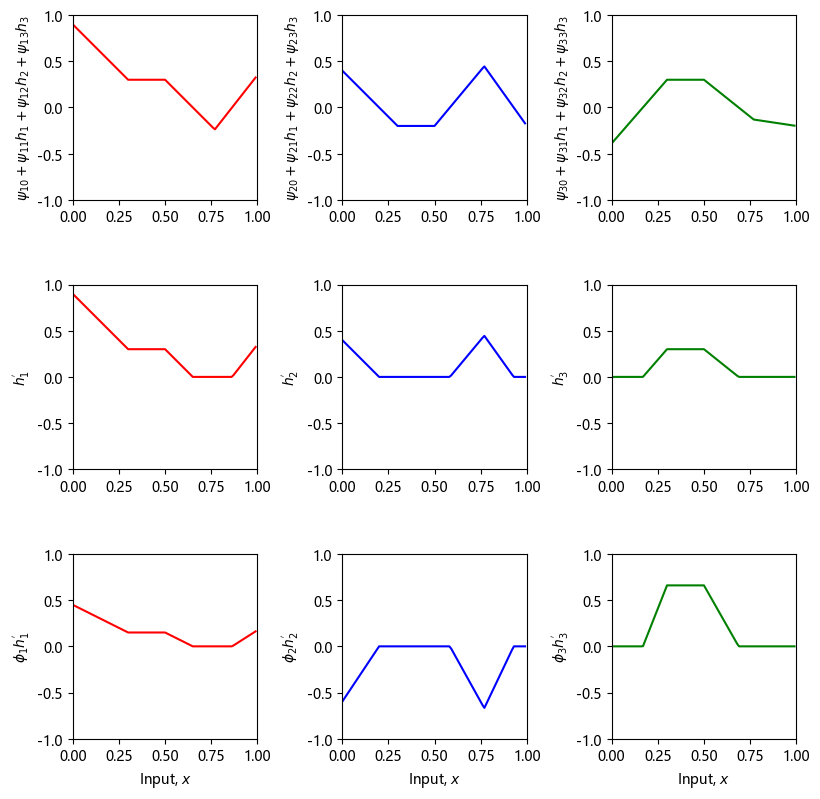

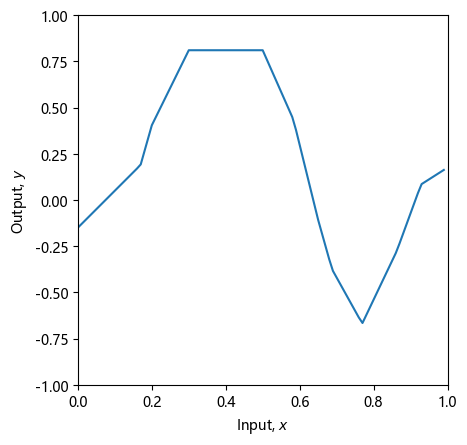

In [5]:
# Define parameters (note first dimension of theta and psi is padded to make indices match
# notation in book)
theta = np.zeros([4,2])
psi = np.zeros([4,4])
phi = np.zeros([4,1])

theta[1,0] =  0.3 ; theta[1,1] = -1.0
theta[2,0]= -1.0  ; theta[2,1] = 2.0
theta[3,0] = -0.5  ; theta[3,1] = 0.65
psi[1,0] = 0.3;  psi[1,1] = 2.0; psi[1,2] = -1.0; psi[1,3]=7.0
psi[2,0] = -0.2;  psi[2,1] = 2.0; psi[2,2] = 1.2; psi[2,3]=-8.0
psi[3,0] = 0.3;  psi[3,1] = -2.3; psi[3,2] = -0.8; psi[3,3]=2.0
phi[0] = 0.0; phi[1] = 0.5; phi[2] = -1.5; phi [3] = 2.2

# Define a range of input values
x = np.arange(0,1,0.01)

# Run the neural network
y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime \
    = shallow_1_1_3_3(x, ReLU, phi, psi, theta)

# And then plot it
plot_neural_two_layers(x, y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime)

To do:  To test your understanding of this, consider:

1.   What would happen if we increase $\psi_{1,0}$?
2.   What would happen if we multiplied $\psi_{2,0}, \psi_{2,1}, \psi_{2,2},  \psi_{2,3}$ by -1?
3.  What would happen if set $\phi_{3}$ to -1?

You can rerun the code to see if you were correct.



In [6]:
# 三个思考题：预测、独立改动、观测、解释。
base=shallow_1_1_3_3_debug(x,ReLU,phi,psi,theta)
variants={}
for bias in (.30,.45,.60):
    p=psi.copy();p[1,0]=bias;d=shallow_1_1_3_3_debug(x,ReLU,phi,p,theta);variants[bias]=d
    sign=np.signbit(d["layer2_pre"][0]); roots=x[1:][sign[1:]!=sign[:-1]]
    print(f"psi[1,0]={bias:.2f}: min={d['layer2_pre'][0].min():.6f}, 采样确认的过零邻域={roots.tolist()}")
np.testing.assert_allclose(variants[.30]["layer2_pre"][0].min(),-31/130,atol=2e-3)
assert variants[.45]["layer2_pre"][0].min()<0
np.testing.assert_allclose(variants[.60]["layer2_pre"][0].min(),4/65,atol=2e-3)
p_flip=psi.copy();p_flip[2,0:4]*=-1;flip=shallow_1_1_3_3_debug(x,ReLU,phi,p_flip,theta)
np.testing.assert_allclose(flip["layer2_pre"][1],-base["layer2_pre"][1])
assert not np.allclose(flip["layer2_act"][1],-base["layer2_act"][1])
phi3=phi.copy();phi3[3,0]=-1;changed=shallow_1_1_3_3_debug(x,ReLU,phi3,psi,theta)
np.testing.assert_allclose(changed["layer2_pre"],base["layer2_pre"])
np.testing.assert_allclose(changed["layer2_act"],base["layer2_act"])
print("psi 第2行整体变号：z'_2→-z'_2，但 ReLU(-z'_2) 一般不等于 -ReLU(z'_2)。")
print("phi[3] 改为-1：两层隐藏预激活/激活完全不变，仅第三加权贡献和总输出改变。")

psi[1,0]=0.30: min=-0.236500, 采样确认的过零邻域=[0.65, 0.87]
psi[1,0]=0.45: min=-0.086500, 采样确认的过零邻域=[0.73, 0.81]
psi[1,0]=0.60: min=0.063500, 采样确认的过零邻域=[]
psi 第2行整体变号：z'_2→-z'_2，但 ReLU(-z'_2) 一般不等于 -ReLU(z'_2)。
phi[3] 改为-1：两层隐藏预激活/激活完全不变，仅第三加权贡献和总输出改变。


In [7]:
# 小型解析切分：第一层阈值 + 第二层预激活在各仿射段的零点，最终合并相邻同式。
def clipping_regions(phi,psi,theta,lo=0.,hi=1.):
    cuts={lo,hi}
    for b,w in theta[1:]:
        if w and lo < -b/w < hi: cuts.add(float(-b/w))
    first=sorted(cuts); allcuts=set(first)
    for l,r in zip(first[:-1],first[1:]):
        m=(l+r)/2; on=theta[1:,0]+theta[1:,1]*m>0
        for row in psi[1:]:
            a=float(np.sum(row[1:]*theta[1:,1]*on));b=float(row[0]+np.sum(row[1:]*theta[1:,0]*on))
            if a and l < -b/a < r: allcuts.add(-b/a)
    pieces=[];edges=sorted(allcuts)
    for l,r in zip(edges[:-1],edges[1:]):
        m=(l+r)/2;on1=theta[1:,0]+theta[1:,1]*m>0
        za=psi[1:,1:]@(theta[1:,1]*on1);zb=psi[1:,0]+psi[1:,1:]@(theta[1:,0]*on1);on2=za*m+zb>0
        a=float(np.sum(phi[1:,0]*za*on2));b=float(phi[0,0]+np.sum(phi[1:,0]*zb*on2));pieces.append([l,r,a,b])
    merged=[]
    for p in pieces:
        if merged and np.allclose(merged[-1][2:],p[2:],atol=1e-12): merged[-1][1]=p[1]
        else: merged.append(p)
    return merged
regions=clipping_regions(phi,psi,theta);assert len(regions)==11
print("原参数最终输出的最大连续线性区域数=",len(regions))
for i,p in enumerate(regions,1):print(i,*[f"{v:.9g}" for v in p])

原参数最终输出的最大连续线性区域数= 11
1 0 0.169565217 2 -0.15
2 0.169565217 0.2 7.06 -1.008
3 0.2 0.3 4.06 -0.408
4 0.3 0.5 0 0.81
5 0.5 0.583333333 -4.52 3.07
6 0.583333333 0.65 -8.12 5.17
7 0.65 0.6875 -7.12 4.52
8 0.6875 0.769230769 -3.6 2.1
9 0.769230769 0.862745098 4.2 -3.9
10 0.862745098 0.928571429 5.475 -5
11 0.928571429 1 1.275 -1.1


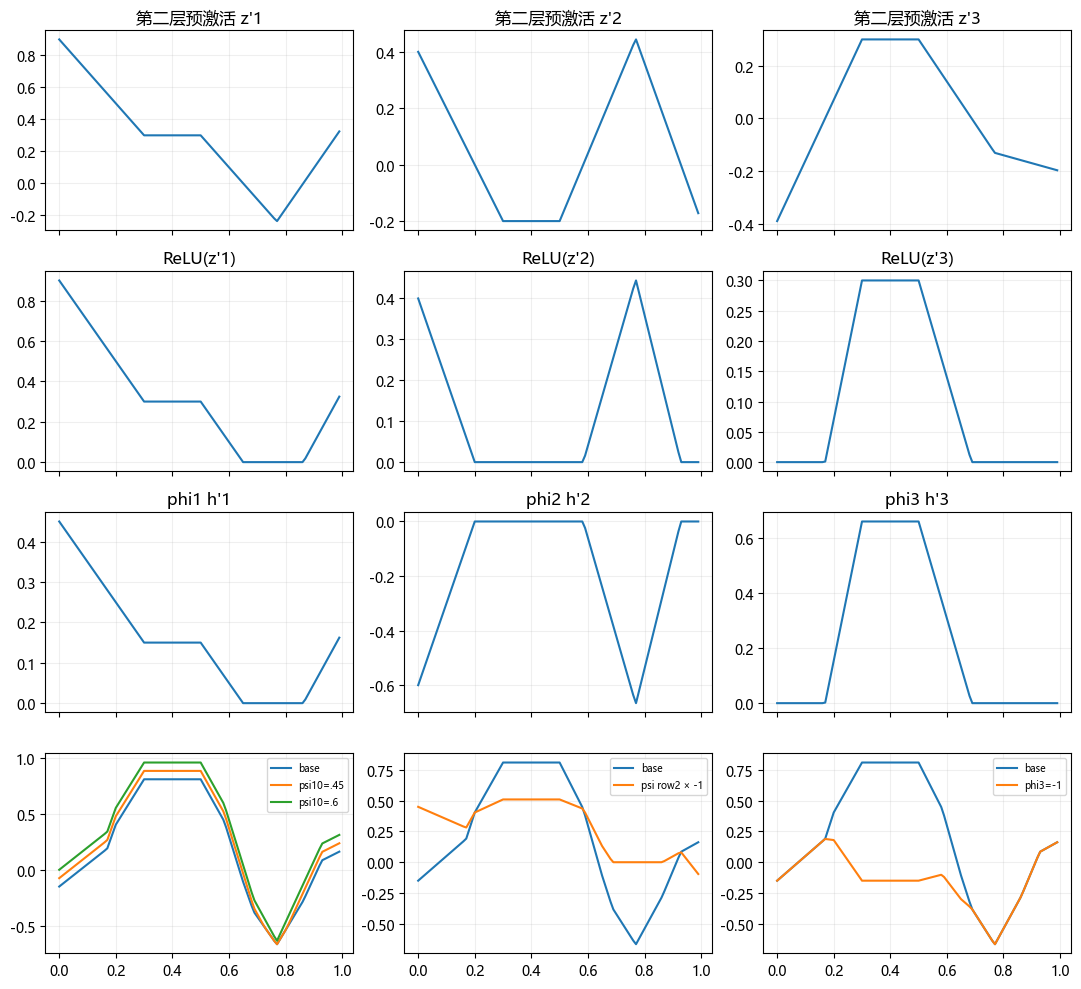

恒等激活展开为单一仿射映射，最大拟合残差= 3.552713678800501e-15


In [8]:
# 教材要求的完整机制图，以及三个变参的可归因对照。
fig,ax=plt.subplots(4,3,figsize=(11,10),sharex=True)
for j in range(3):
    ax[0,j].plot(x,base["layer2_pre"][j]);ax[0,j].set_title(f"第二层预激活 z'{j+1}")
    ax[1,j].plot(x,base["layer2_act"][j]);ax[1,j].set_title(f"ReLU(z'{j+1})")
    ax[2,j].plot(x,base["weighted"][j]);ax[2,j].set_title(f"phi{j+1} h'{j+1}")
    ax[3,j].plot(x,base["y"],label='base')
ax[3,0].plot(x,variants[.45]["y"],label='psi10=.45');ax[3,0].plot(x,variants[.60]["y"],label='psi10=.6')
ax[3,1].plot(x,flip["y"],label='psi row2 × -1');ax[3,2].plot(x,changed["y"],label='phi3=-1')
for a in ax.ravel():
    a.grid(alpha=.2)
    handles, labels = a.get_legend_handles_labels()
    if handles:
        a.legend(fontsize=7)
fig.tight_layout();plt.show()
identity=shallow_1_1_3_3_debug(x,lambda a:a,phi,psi,theta)["y"]
coef=np.polyfit(x,identity,1);res=np.max(np.abs(identity-np.polyval(coef,x)))
print("恒等激活展开为单一仿射映射，最大拟合残差=",res)